<a href="https://colab.research.google.com/github/bijayrepo/AI-ML_Models/blob/main/Facedetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os,time,math,glob
import torch
import cv2
import numpy as np
from pathlib import Path
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [2]:
folder_animal="/content/Images/animal"
animal_image_paths=glob.glob(folder_animal+"/*")
folder_human="/content/Images/human"
human_image_paths=glob.glob(folder_human+"/*")

In [3]:
for path in animal_image_paths[:5]:
  img=cv2.imread(path)
  img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

  plt.figure(figsize=(5,5))
  plt.imshow(img)
  plt.title(path)
  plt.axis("off")
  plt.show()

In [4]:
for path in human_image_paths[:5]:
  img=cv2.imread(path)
  img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

  plt.figure(figsize=(5,5))
  plt.imshow(img)
  plt.title(path)
  plt.axis("off")
  plt.show()

In [8]:
from PIL import Image
import numpy as np

def create_dummy_image(filepath, color=(255, 0, 0), size=(100, 100)):
    os.makedirs(Path(filepath).parent, exist_ok=True)
    img_array = np.zeros((*size, 3), dtype=np.uint8)
    img_array[:, :] = color  # Fill with the specified color
    img = Image.fromarray(img_array)
    img.save(filepath)
    print(f"Created dummy image at: {filepath}")

# Create dummy animal images
for i in range(5):
    create_dummy_image(f"{folder_animal}/animal_{i}.png", color=(255, 100, 0))

# Create dummy human images
for i in range(5):
    create_dummy_image(f"{folder_human}/human_{i}.png", color=(0, 100, 255))


Created dummy image at: /content/Images/animal/animal_0.png
Created dummy image at: /content/Images/animal/animal_1.png
Created dummy image at: /content/Images/animal/animal_2.png
Created dummy image at: /content/Images/animal/animal_3.png
Created dummy image at: /content/Images/animal/animal_4.png
Created dummy image at: /content/Images/human/human_0.png
Created dummy image at: /content/Images/human/human_1.png
Created dummy image at: /content/Images/human/human_2.png
Created dummy image at: /content/Images/human/human_3.png
Created dummy image at: /content/Images/human/human_4.png


In [9]:
folder_animal="/content/Images/animal"
animal_image_paths=glob.glob(folder_animal+"/*")
folder_human="/content/Images/human"
human_image_paths=glob.glob(folder_human+"/*")

print(f"Found {len(animal_image_paths)} animal images.")
print(f"Found {len(human_image_paths)} human images.")

Found 5 animal images.
Found 5 human images.


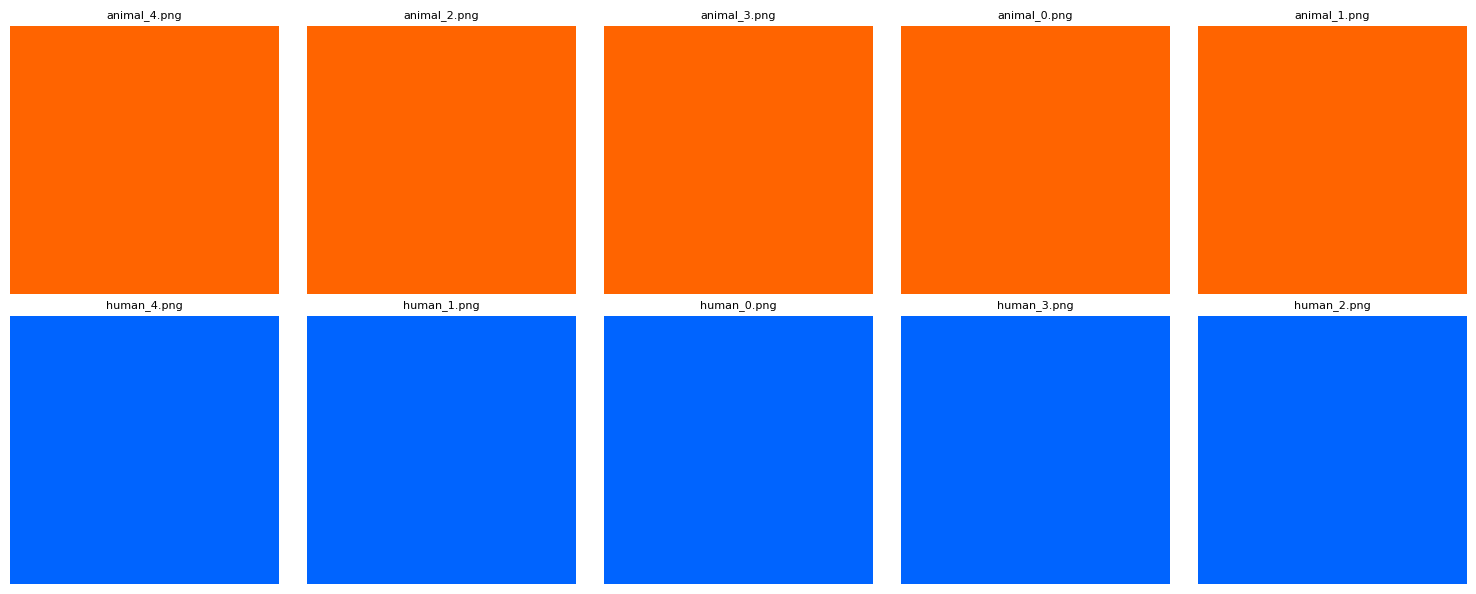

In [10]:
all_image_paths = animal_image_paths + human_image_paths

# Determine grid size (e.g., 5 images per row)
n_images = len(all_image_paths)
n_cols = 5
n_rows = math.ceil(n_images / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, path in enumerate(all_image_paths):
    if i < len(axes):
        img = cv2.imread(path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(Path(path).name, fontsize=8)
            axes[i].axis("off")
        else:
            print(f"Warning: Could not read image at {path}")
    else:
        break # Should not happen if n_rows, n_cols are calculated correctly

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()